In [1]:
import pandas as pd

df = pd.read_csv(r"F:\EARTH_SYSTEM_ML_PROJECT\data\raw\pbdb\pbdb_fossils.csv",
                 low_memory=False)

df.head()

,occurrence_no,record_type,reid_no,flags,collection_no,identified_name,identified_rank,identified_no,difference,accepted_name,...,formation,geological_group,member,lithdescript,lithology1,lithification1,minor_lithology1,lithology2,lithification2,minor_lithology2
0,41524,occ,NaN,NaN,3257,Aves indet.,class,NaN,NaN,Aves,...,NaN,Bracklesham,NaN,NaN,sandstone,NaN,NaN,NaN,NaN,NaN
1,41580,occ,NaN,NaN,3256,Aves indet.,class,NaN,NaN,Aves,...,NaN,Bracklesham,NaN,NaN,sandstone,NaN,NaN,NaN,NaN,NaN
2,130209,occ,NaN,NaN,10755,Chaoyangosaurus liaosiensis n. gen. n. sp.,species,65704.0,NaN,Chaoyangsaurus youngi,...,Tuchengzi,NaN,NaN,purple-grey sediments representing a river-facies,mudstone,NaN,NaN,NaN,NaN,NaN
3,130294,occ,NaN,NaN,10764,Protarchaeopteryx robusta n. gen. n. sp.,species,NaN,NaN,Protarchaeopteryx robusta,...,Yixian,Jehol,Jianshangou,NaN,siltstone,NaN,NaN,NaN,NaN,NaN
4,130295,occ,NaN,NaN,10764,Caudipteryx zoui n. gen. n. sp.,species,NaN,NaN,Caudipteryx zoui,...,Yixian,Jehol,Jianshangou,NaN,siltstone,NaN,NaN,NaN,NaN,NaN


In [2]:
df = df.dropna(subset=["lat", "lng", "early_interval"])

taxon_col = "accepted_name" if "accepted_name" in df.columns else "identified_name"

In [3]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["time_encoded"] = le.fit_transform(df["early_interval"])

In [4]:
features = df[["lat", "lng", "time_encoded"]]

In [5]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(features)

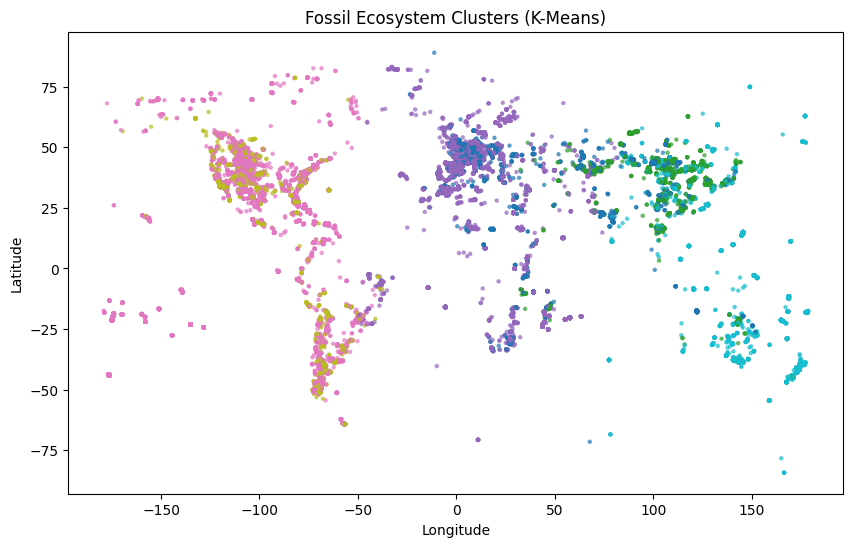

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    df["lng"],
    df["lat"],
    c=df["cluster"],
    cmap="tab10",
    s=5,
    alpha=0.6
)

plt.title("Fossil Ecosystem Clusters (K-Means)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [7]:
summary = df.groupby("cluster").agg(
    avg_lat=("lat", "mean"),
    avg_lng=("lng", "mean"),
    diversity=(taxon_col, "nunique"),
    count=("occurrence_no", "count")
)

print(summary)

           avg_lat     avg_lng  diversity  count
cluster                                         
0        30.592048   46.473367       1375   4497
1        30.850530  107.106062        748   2370
2        32.763919    8.464287       1518   8390
3        26.965982 -102.878367       2490  14378
4        23.316103  -97.644179       1217   4078
5        -5.893511  144.262665       1215   4077
